In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load Data
file_path = '/content/GS668 Assignment -3 data.txt'
with open(file_path, 'r') as f:
    data = np.array([float(line.strip()) for line in f if line.strip()])

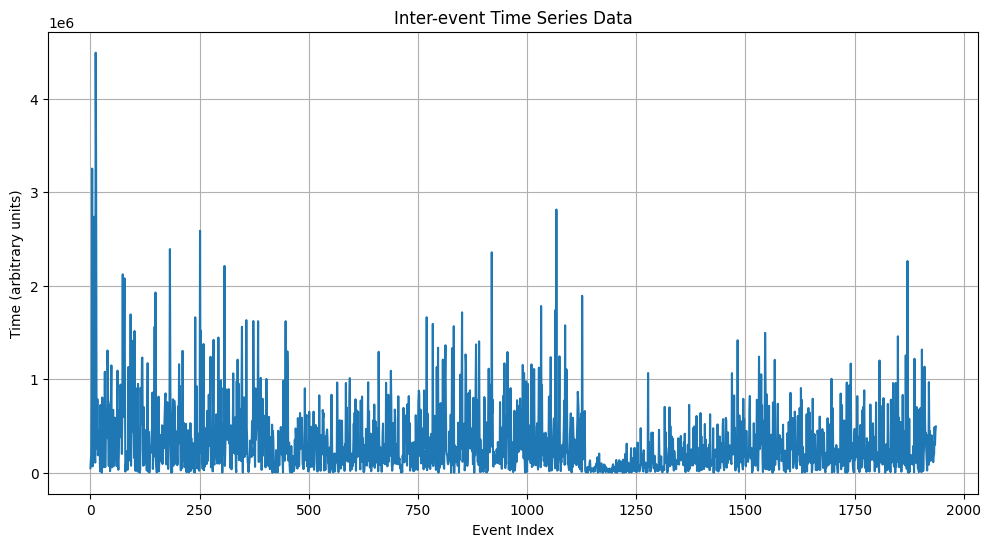

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(data)
plt.title('Inter-event Time Series Data')
plt.xlabel('Event Index')
plt.ylabel('Time (arbitrary units)')
plt.grid(True)
plt.show()

In [ ]:
#  Setup Parameters
q_list = np.linspace(-5, 5, 21)
s_list = np.unique(np.logspace(np.log10(10), np.log10(len(data)//4), 15).astype(int))
order = 1
f_q_s = np.zeros((len(q_list), len(s_list)))

#  Profile Calculation (Cumulative Sum)
y = np.cumsum(data - np.mean(data))


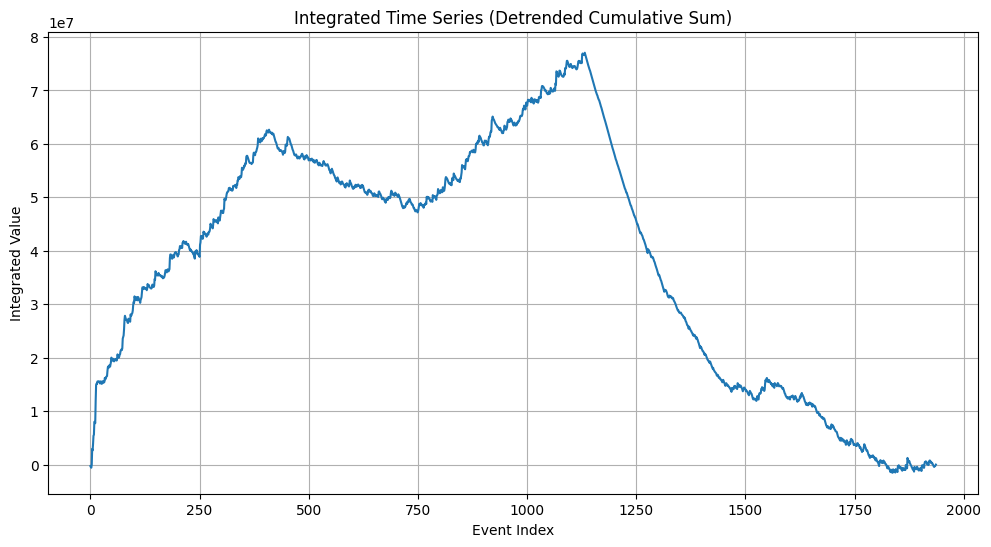

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y)
plt.title('Integrated Time Series (Detrended Cumulative Sum)')
plt.xlabel('Event Index')
plt.ylabel('Integrated Value')
plt.grid(True)
plt.show()

In [ ]:

#  Loop through Scales (s) and Calculate RMS
for i, s in enumerate(s_list):
    # Forward and Backward segments
    num_segments = len(y) // s
    segments = [y[j*s : (j+1)*s] for j in range(num_segments)]
    segments += [y[len(y)-(j+1)*s : len(y)-j*s] for j in range(num_segments)]

    rms = []
    x = np.arange(s)
    for seg in segments:
        # Fit polynomial and calculate Root Mean Square error
        poly = np.polyfit(x, seg, order)
        rms.append(np.sqrt(np.mean((seg - np.polyval(poly, x))**2)))

    rms = np.array(rms)

    # Calculate Fluctuation Function F_q(s)
    for j, q in enumerate(q_list):
        if q == 0:
            f_q_s[j, i] = np.exp(0.5 * np.mean(np.log(rms**2)))
        else:
            f_q_s[j, i] = (np.mean(rms**q))**(1.0/q)


In [ ]:
# Calculate Scaling Exponents h(q) and tau(q)
h_q = []
for j in range(len(q_list)):
    # Linear fit in log-log space to find slope
    slope, intercept = np.polyfit(np.log(s_list), np.log(f_q_s[j, :]), 1)
    h_q.append(slope)

h_q = np.array(h_q)
tau_q = q_list * h_q - 1

In [ ]:
print("Scaling Exponents (h(q)):", h_q)
print

Scaling Exponents (h(q)): [1.11535026 1.0936242  1.06687091 1.03357984 0.99206872 0.94118255
 0.88215886 0.82147689 0.76999172 0.73395387 0.71114051 0.69659299
 0.68621567 0.67707818 0.66710486 0.65502736 0.64054887 0.62431755
 0.60746523 0.59102504 0.57564316]


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [ ]:
# Legendre Transform for Alpha and f(Alpha)
alpha = np.gradient(tau_q, q_list)
f_alpha = q_list * alpha-tau_q

Singularity Width (Delta Alpha): 0.8737


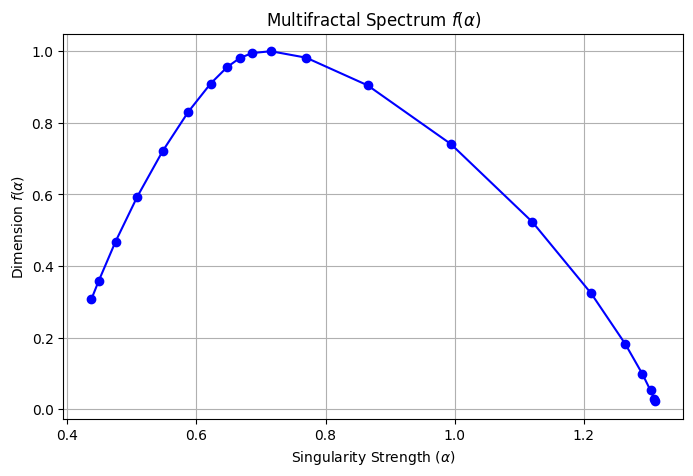

In [ ]:
# Results and Plotting
print(f"Singularity Width (Delta Alpha): {max(alpha) - min(alpha):.4f}")

plt.figure(figsize=(8, 5))
plt.plot(alpha, f_alpha, 'bo-')
plt.title('Multifractal Spectrum $f(\\alpha)$')
plt.xlabel('Singularity Strength $(\\alpha)$')
plt.ylabel('Dimension $f(\\alpha)$')
plt.grid(True)
plt.show()

The multifractal analysis of inter-event time series data from the global earthquake catalog provides insights into the scaling properties and heterogeneity of the dataset. Here's an interpretation of the results

The singularity width, calculated as the difference between the maximum and minimum values of $\alpha$ (alpha), is **0.8737**. This value quantifies the extent of multifractality in the data. A larger singularity width indicates a more heterogeneous and complex system, with a wider range of scaling behaviors across different parts of the time series. In the context of earthquake inter-event times, this suggests that the distribution of waiting times between earthquakes is not uniform but rather exhibits significant variability, consistent with complex seismic processes.


The shape of  $f(\alpha)$ curve, which is generally an inverted parabola-like shape, confirms the presence of multifractality. The width of this curve reflects the range of singularity exponents present in the data, directly related to the singularity width discussed above and right skewed spectrum corresponds to finer structure. A broad and asymmetric spectrum indicates strong multifractality, suggesting that the earthquake inter-event times are governed by a variety of different scaling laws, rather than a single one.


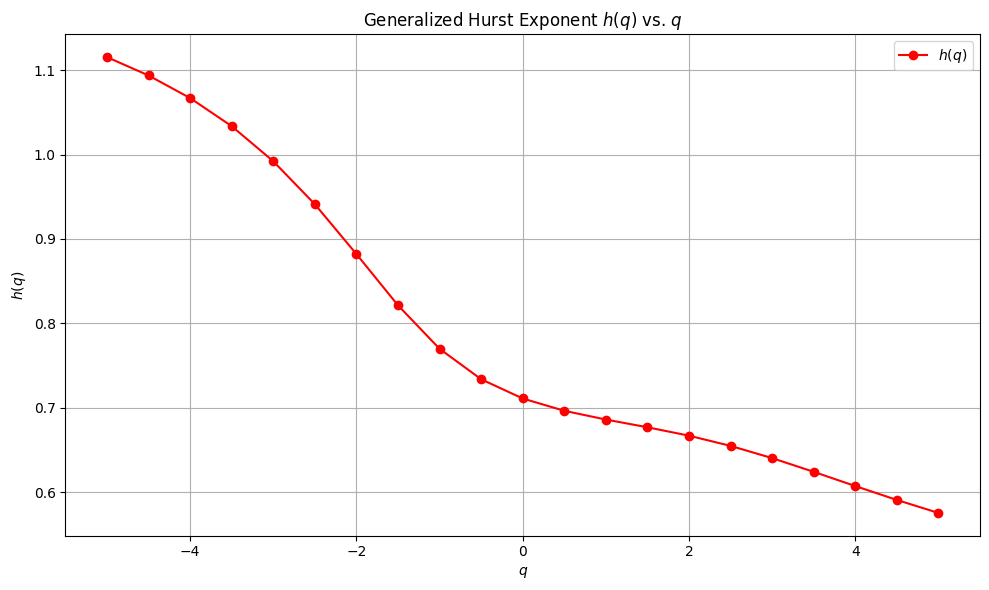

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(q_list, h_q, 'ro-', label='$h(q)$')
plt.title('Generalized Hurst Exponent $h(q)$ vs. $q$')
plt.xlabel('$q$')
plt.ylabel('$h(q)$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()




  For multifractal data, $h(q)$ is not constant; it varies with $q$. This variation is the key signature of multifractality. It tells us that different parts of the time series (or different magnitudes of fluctuations) scale differently. The system possesses a spectrum of scaling exponents rather than a single one.

  **The shape of the $h(q)$ curve:**
      Typically, for multifractal processes, $h(q)$ is a **decreasing function of $q$**. This is generally observed in your plot, where $h(q)$ starts higher for negative $q$ and decreases as $q$ increases.
      **Higher $h(q)$ values for negative $q$** indicate that small fluctuations are characterized by stronger persistence (or weaker anti-persistence).
    **Lower $h(q)$ values for positive $q$** suggest that large fluctuations might be less persistent or have different scaling properties.

In the context of earthquake inter-event times, this varying $h(q)$ curve strongly suggests that the underlying processes governing the time between earthquakes are complex and heterogeneous, with different scaling behaviors for small and large inter-event intervals.